In [136]:
%pip install ipython-sql
# %sql SELECT name FROM sqlite_master WHERE type='table'

Note: you may need to restart the kernel to use updated packages.


In [137]:
%config SqlMagic.style = '_DEPRECATED_DEFAULT'

In [138]:
%load_ext sql

The sql extension is already loaded. To reload it, use:
  %reload_ext sql


In [151]:
import numpy as np
import pandas as pd

In [152]:
chemin = r"C:\Users\USER\Desktop\Learning Data Analyst\DataRockStar\Projet Fil Rouge\mon_projet\data\demographie-secteurs-conventionnels.csv"
df1 = pd.read_csv(chemin, sep=";", encoding="utf-8-sig")

In [153]:
df1 = df1.rename(columns={
    "departement": "code_dep",
    "libelle_departement": "libelle_dep",
    "effectif" : "effectif_medecins"
})
df1 = df1.drop(columns=["region", "vision generale all", "vision_generale_prescriptions", "vision profession territoire"])
df1["secteur_conventionnel"] = df1["secteur_conventionnel"].astype(str)
df1 = df1[df1["profession_sante"].isin(["Médecins généralistes (hors médecins à expertise particulière - MEP)", "Médecins généralistes à expertise particulière (MEP)"])].reset_index(drop=True)
df1 = df1.replace({"code_dep" : {"999" : np.nan},
                    "annee" : {2024 : np.nan}}).dropna()
df1["code_dep"] = df1["code_dep"].str.zfill(2)
df1 = df1.replace({'libelle_secteur_conventionnel': {
    "conventionnés de secteur 2 ayant adhéré à l'Optam/Optam-CO": "conventionnés de secteur 2",
    "conventionnés de secteur 2 n'ayant pas adhéré à l'Optam/Optam-CO": "conventionnés de secteur 2"
}})

In [154]:
# Créer une ligne avec un total
df1_total = df1.groupby(["code_dep", "annee"], as_index=False)["effectif_medecins"].sum()

# Ajout d'une valeur spécifique dans les colonnes où total devra apparaître
df1_total["profession_sante"] = "Tous médecins généralistes"
df1_total["libelle_secteur_conventionnel"] = "tout secteur compris"
df1_total["secteur_conventionnel"] = "_T"

libelles = df1[["code_dep", "libelle_region", "libelle_dep"]].drop_duplicates()
df1_total = pd.merge(df1_total, libelles, on="code_dep", how="left")
# pd.concat() s'applique sur : liste de DataFrames → retourne un DataFrame
df1 = pd.concat([df1, df1_total], ignore_index=True)

In [155]:
ok_year = [int(year) for year in df1['annee'].unique()]

In [156]:
#df min/max => 2010/2024
df2 = pd.read_csv(r"C:\Users\USER\Desktop\Learning Data Analyst\DataRockStar\Projet Fil Rouge\mon_projet\data\DS_POPULATIONS_HISTORIQUES_data.csv", sep=";")


C:\Users\USER\AppData\Local\Temp\ipykernel_13256\909426725.py:2: DtypeWarning: Columns (0: GEO) have mixed types. Specify dtype option on import or set low_memory=False.
  df2 = pd.read_csv(r"C:\Users\USER\Desktop\Learning Data Analyst\DataRockStar\Projet Fil Rouge\mon_projet\data\DS_POPULATIONS_HISTORIQUES_data.csv", sep=";")


In [157]:
# Index(['FREQ', 'GEO', 'GEO_OBJECT', 'POPREF_MEASURE', 'TIME_PERIOD', 'OBS_VALUE'])
# année min/max => 2010/2024
# Je supprime toutes les lignes inutiles pour ne garder que les lignes avec les années souhaitées (entre 2010 et 2024 incluses) 
# et les lignes traitant des départements
df2 = df2[df2["TIME_PERIOD"].isin(ok_year)]
df2 = df2[df2["GEO_OBJECT"] == "DEP"].reset_index(drop=True)
# Je supprimes les colonnes inutiles
df2 = df2.drop(columns=["FREQ", "GEO_OBJECT", "POPREF_MEASURE"])
# Je standardise les noms de colonnes
df2 = df2.rename(columns={
    "GEO": "code_dep",
    "TIME_PERIOD": "annee",
    "OBS_VALUE" : "nombre_residents"
})
df2.columns = df2.columns.str.lower()


In [158]:
df_densite_medecin = pd.merge(
    df1,
    df2,
    on=["code_dep", "annee"],
    how="inner"
)
# Attention, un département aura 8 lignes + 1 total pour une annee dans df1, mais 1 ligne pour une annee dans df2.

In [159]:
df3 = pd.read_csv(r"C:\Users\USER\Desktop\Learning Data Analyst\DataRockStar\Projet Fil Rouge\mon_projet\data\DS_DECES_MORTALITE_SERIES_data.csv", sep=";")

In [160]:
# # lecture des métadonnées de décès, et choix de ce que je garde
# chemin3 = r"C:\Users\USER\Desktop\Learning Data Analyst\DataRockStar\Projet Fil Rouge\data utiles au projet\DS_DECES_MORTALITE_SERIES_CSV_FR\DS_DECES_MORTALITE_SERIES_metadata.csv"
# df3_meta = pd.read_csv(chemin3, sep=";")
# to_keep = ["OBS_VALUE", "DECIMALS","EC_MEASURE", "UNIT_MEASURE", "SEX", "AGE", "OBS_STATUS", "OBS_STATUS_FR"]
# df3_meta = df3_meta[df3_meta["COD_VAR"].isin(to_keep)].reset_index(drop=True)
# df3_meta = df3_meta.drop(columns="GEO_OBJECT")
# df3_meta


In [161]:
# code_age = df3_meta[df3_meta["COD_VAR"] == "AGE"][["COD_VAR", "LIB_VAR","COD_MOD", "LIB_MOD"]]
# for ca in code_age.COD_MOD.values:
#     if ca not in df3["AGE"].values:
#         code_age["COD_MOD"] = code_age["COD_MOD"].replace(ca, np.nan)
# code_age = code_age.dropna().reset_index(drop=True)
# keepers = pd.concat([(df3_meta.iloc[[26, 30, 33, 36, 38, 39, 40]]), (code_age.iloc[[1, 5, 6, 7]])], axis=0)
# keepers

In [162]:
# Suppression des lignes inutiles pour mes analyses cf keepers
# Suppression des lignes qui ne contiennent pas de données départementales
# Suppression des lignes hors des années étudiées (2010 à 2023)
df3 = df3[
    (df3["GEO_OBJECT"] == "DEP") 
    & (df3["FREQ"] == "A")
    & (df3["OBS_STATUS"] == "A")
    & (df3["OBS_STATUS_FR"] == "D")
    & (df3["EC_MEASURE"].isin(["DTH_PLACE_RES", "MOR_STANDARD_RT"]))
    & (df3["AGE"].isin(["Y_LT1", "Y_LT65", "Y_GE65", "_T"]))]
df3["TIME_PERIOD"] = df3["TIME_PERIOD"].astype(int)
df3 = df3[(df3["TIME_PERIOD"].isin(ok_year))]

df3 = df3.rename(columns={
    "GEO": "code_dep",
    "TIME_PERIOD": "annee",
    "OBS_VALUE" : "nombre_deces",
    "EC_MEASURE" : "type_mesure"
})
df3.columns = df3.columns.str.lower()

In [163]:
# Suppression des colonnes contenant la même valeur unique
for col in df3.columns:
    if len(df3[col].unique()) == 1:
        df3 = df3.drop(columns=col)

In [164]:
df3.head(3)

,code_dep,age,type_mesure,unit_measure,decimals,annee,nombre_deces
1,75,_T,DTH_PLACE_RES,NR,0,2013,13939.0
7,75,_T,DTH_PLACE_RES,NR,0,2011,13771.0
11,78,_T,DTH_PLACE_RES,NR,0,2011,8430.0


In [165]:
df_med = df1
df_med = df_med[df_med["secteur_conventionnel"] == "_T"]
df_med = df_med[["code_dep", "annee", "libelle_dep", "effectif_medecins"]]

In [ ]:
df_pop = df2
df_deces = df3
df_deces = df_deces[(df_deces["age"] == "_T") & (df_deces["type_mesure"] == "DTH_PLACE_RES")]
df_deces = df_deces[["code_dep", "annee", "nombre_deces"]]


In [169]:
df_densite_totale = (df_med.merge(df_pop, on=["code_dep", "annee"], how="inner")
                            .merge(df_deces, on=["code_dep", "annee"], how="inner"))
df_densite_totale["densite_medicale_100k"] = df_densite_totale["effectif_medecins"] / df_densite_totale["nombre_residents"] * 100000

In [170]:
df_densite_totale.head()

,code_dep,annee,libelle_dep,effectif_medecins,nombre_residents,nombre_deces,densite_medicale_100k
0,01,2010.0,Ain,445,597341,4449.0,74.496812
1,01,2011.0,Ain,446,603827,4305.0,73.862216
2,01,2012.0,Ain,452,612191,4577.0,73.833166
3,01,2013.0,Ain,446,619497,4565.0,71.993892
4,01,2014.0,Ain,442,626127,4542.0,70.592707


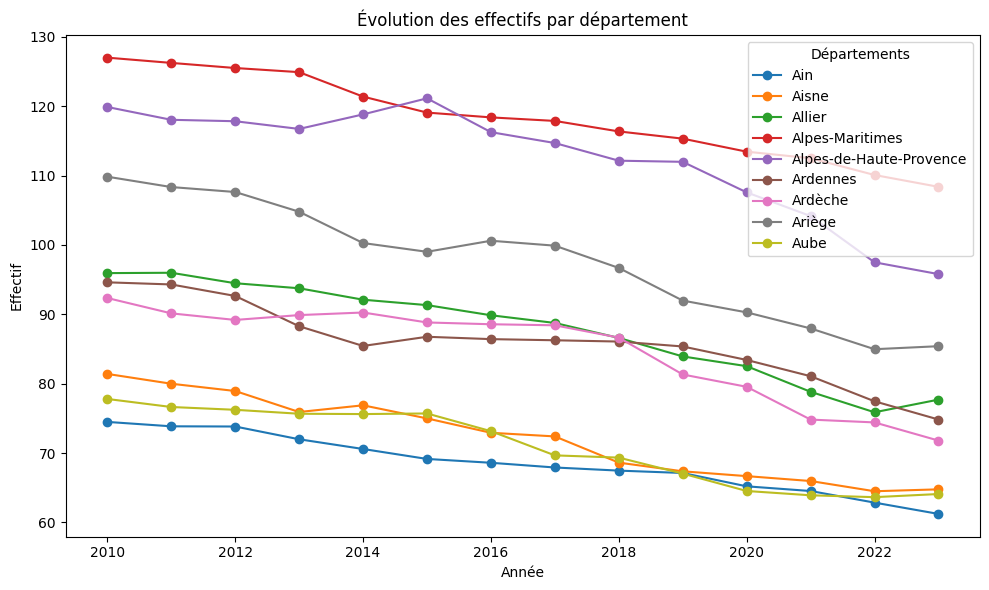

In [171]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(10,6))
x = 0
for dept, groupe in df_densite_totale.groupby('libelle_dep'):
    x += 1
    if x < 10:
        ax.plot(groupe['annee'], groupe['densite_medicale_100k'], marker='o', label=dept)
    else:
        break

ax.set_title("Évolution des effectifs par département")
ax.set_xlabel("Année")
ax.set_ylabel("Effectif")
ax.legend(title="Départements")
plt.tight_layout()
plt.show()

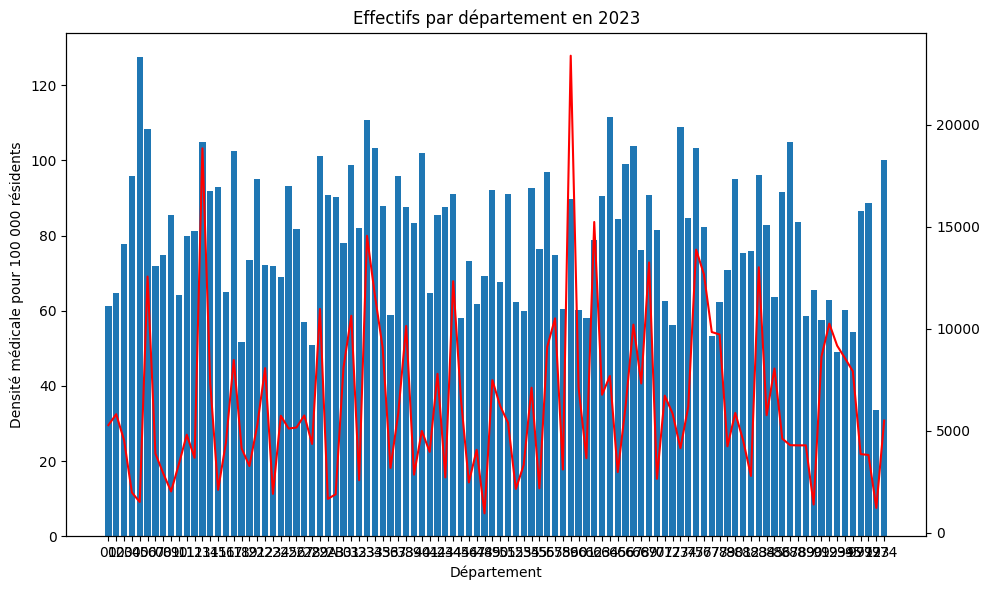

In [181]:
# S'applique sur un DataFrame → retourne un DataFrame filtré
df_2023 = df_densite_totale[df_densite_totale['annee'] == 2023]

# Ensuite un simple barplot (plus logique qu'un lineplot pour une seule année)
fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(df_2023['code_dep'], df_2023['densite_medicale_100k'])
ax2 = ax.twinx()
ax2.plot(df_2023['code_dep'], df_2023['nombre_deces'], color='red')
ax.set_title("Effectifs par département en 2023")
ax.set_xlabel("Département")
ax.set_ylabel("Densité médicale pour 100 000 résidents")
plt.tight_layout()
plt.show()

In [ ]:
import plotly.express as px
import requests

# --- 1. Récupérer le GeoJSON des départements français ---
geojson_url = "https://raw.githubusercontent.com/gregoiredavid/france-geojson/master/departements-version-simplifiee.geojson"
geojson_dept = requests.get(geojson_url).json()

# --- 2. Ta carte choroplèthe ---
fig = px.choropleth(
    df2,                          # ton dataframe
    geojson=geojson_dept,        # les formes géographiques
    locations="code_dep", # colonne avec les codes département (01, 02... 974)
    featureidkey="properties.code", # clé dans le GeoJSON qui correspond à tes codes
    color="obs_value",      # colonne population → détermine la couleur
    color_continuous_scale="Blues", # dégradé de couleurs (tu peux changer)
    scope="europe",              # zoom sur l'Europe (inclut la France métro)
    labels={"obs_values": "Population"} # légende lisible
)

# --- 3. Recentrer la carte sur la France ---
fig.update_geos(
    center={"lat": 46.5, "lon": 2.5},
    projection_scale=6 # zoom (augmente pour zoomer davantage)
)

fig.update_layout(margin={"r":0,"t":0,"l":0,"b":0})

# fig.show()

ValueError: Value of 'locations' is not the name of a column in 'data_frame'. Expected one of ['FREQ', 'GEO', 'GEO_OBJECT', 'POPREF_MEASURE', 'TIME_PERIOD', 'OBS_VALUE'] but received: code_dep